# Traffic Sign Classification Project

Six classes: stop, speed_limit, no_entry, pedestrian, turn_left, turn_right.

**Data plan (no leakage):**
- `dataset/` (own photos) and `augmented/` (augmented copies of own photos) are used for **training only**.
- `external/` is split once (stratified) into train / validation / test. Only its train share is used for training.
- Test set is touched exactly once, at the end.

In [25]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


## 1. Settings

In [26]:
IMG_SIZE = 128
SEED = 42

classes = [
    "stop",
    "speed_limit",
    "no_entry",
    "pedestrian",
    "turn_left",
    "turn_right",
]
class_to_index = {name: idx for idx, name in enumerate(classes)}

dataset_path = Path("../dataset")
augmented_path = Path("../augmented")
external_path = Path("../external")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

tf.keras.utils.set_random_seed(SEED)

## 2. Load data

In [27]:
def load_images_from_folder(base_path):
    """Load every image in base_path/<class_name>/ -> RGB, resized, scaled to [0, 1]."""
    images, labels = [], []

    for class_name in classes:
        folder = base_path / class_name

        if not folder.exists():
            print(f"WARNING: folder not found: {folder}")
            continue

        loaded = 0
        for path in sorted(folder.iterdir()):
            if path.suffix.lower() not in VALID_EXT:
                continue

            image = cv2.imread(str(path))
            if image is None:
                print(f"Skipping unreadable file: {path}")
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = image.astype(np.float32) / 255.0

            images.append(image)
            labels.append(class_to_index[class_name])
            loaded += 1

        print(f"{base_path.name}/{class_name}: {loaded} images")

    if not images:
        return np.empty((0, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), np.empty((0,), dtype=np.int32)

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


X_original, y_original = load_images_from_folder(dataset_path)
X_augmented, y_augmented = load_images_from_folder(augmented_path)
X_external, y_external = load_images_from_folder(external_path)

print("\nOriginal :", X_original.shape)
print("Augmented:", X_augmented.shape)
print("External :", X_external.shape)

dataset/stop: 5 images
dataset/speed_limit: 4 images
dataset/no_entry: 5 images
dataset/pedestrian: 5 images
dataset/turn_left: 5 images
dataset/turn_right: 5 images
augmented/stop: 90 images
augmented/speed_limit: 90 images
augmented/no_entry: 90 images
augmented/pedestrian: 90 images
augmented/turn_left: 90 images
augmented/turn_right: 90 images
external/stop: 74 images
external/speed_limit: 83 images
external/no_entry: 94 images
external/pedestrian: 96 images
external/turn_left: 45 images
external/turn_right: 38 images

Original : (29, 128, 128, 3)
Augmented: (540, 128, 128, 3)
External : (430, 128, 128, 3)


## 3. Split data

Only `external/` is split. Own photos and their augmented copies go to training only,
so near-duplicate images can never end up in validation or test.

In [28]:
# 60% train / 20% val / 20% test of the external images
X_ext_train, X_tmp, y_ext_train, y_tmp = train_test_split(
    X_external, y_external,
    test_size=0.40, stratify=y_external, random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50, stratify=y_tmp, random_state=SEED,
)

# Training = own originals + own augmented + external train share
X_train = np.concatenate([X_original, X_augmented, X_ext_train], axis=0)
y_train = np.concatenate([y_original, y_augmented, y_ext_train], axis=0)

# Shuffle training data once
perm = np.random.RandomState(SEED).permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

print("Train:", X_train.shape, np.bincount(y_train, minlength=len(classes)))
print("Val:  ", X_val.shape, np.bincount(y_val, minlength=len(classes)))
print("Test: ", X_test.shape, np.bincount(y_test, minlength=len(classes)))

assert all(np.bincount(y_test, minlength=len(classes)) > 0), "A class is missing from the test set"

Train: (827, 128, 128, 3) [139 144 151 153 122 118]
Val:   (86, 128, 128, 3) [15 16 19 19  9  8]
Test:  (86, 128, 128, 3) [15 17 19 19  9  7]


In [29]:
# Class weights to compensate for imbalance (e.g. pedestrian dominating)
weights = compute_class_weight("balanced", classes=np.arange(len(classes)), y=y_train)
class_weight = dict(enumerate(weights))
print("Class weights:", {classes[k]: round(v, 2) for k, v in class_weight.items()})

Class weights: {'stop': np.float64(0.99), 'speed_limit': np.float64(0.96), 'no_entry': np.float64(0.91), 'pedestrian': np.float64(0.9), 'turn_left': np.float64(1.13), 'turn_right': np.float64(1.17)}


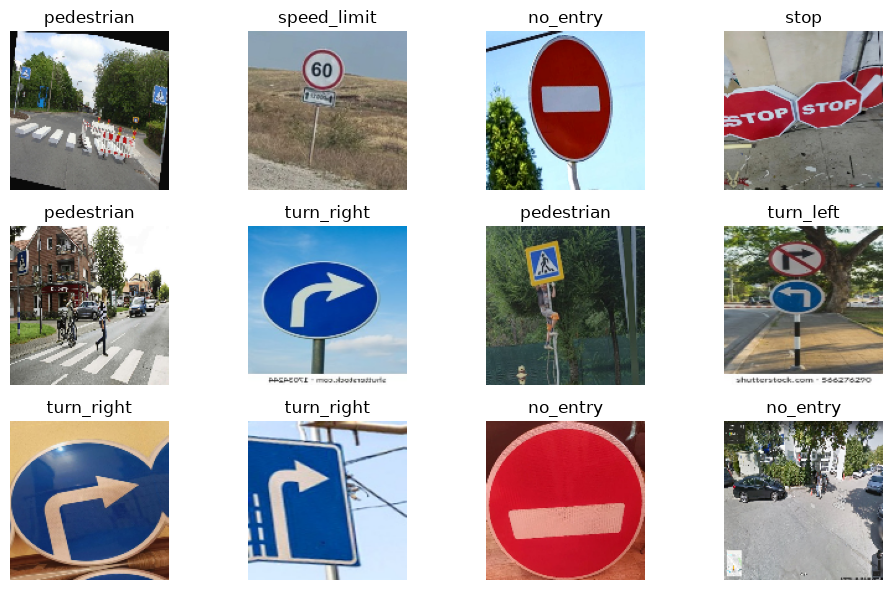

In [30]:
# Preview random training samples
rng = np.random.RandomState(0)
sample_idx = rng.choice(len(X_train), 12, replace=False)

plt.figure(figsize=(10, 6))
for i, idx in enumerate(sample_idx):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[idx])
    plt.title(classes[y_train[idx]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Helpers (callbacks, plotting)

In [48]:
def make_callbacks(patience=6, monitor="val_accuracy"):
    return [
        EarlyStopping(monitor=monitor, mode="max", patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                          min_lr=1e-6, verbose=1),
    ]


def merge_histories(*histories):
    merged = {}
    for h in histories:
        for key, values in h.history.items():
            merged.setdefault(key, []).extend(values)
    return merged


def plot_history(history_dict, title, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict["accuracy"], label="Train")
    axes[0].plot(history_dict["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_dict["loss"], label="Train")
    axes[1].plot(history_dict["val_loss"], label="Validation")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    if save_name:
        plt.savefig(RESULTS_DIR / save_name, dpi=150)
    plt.show()

## 5. Baseline CNN

Small, plain CNN with no augmentation or regularization. This is the baseline to beat.

In [32]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(len(classes), activation="softmax"),
    ], name="baseline_cnn")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


baseline_model = build_baseline_model()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.4534 - loss: 1.4053 - val_accuracy: 0.3140 - val_loss: 1.8576 - learning_rate: 0.0010
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7666 - loss: 0.7364 - val_accuracy: 0.5581 - val_loss: 1.3171 - learning_rate: 0.0010
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8791 - loss: 0.4047 - val_accuracy: 0.6512 - val_loss: 1.1933 - learning_rate: 0.0010
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9299 - loss: 0.2533 - val_accuracy: 0.7326 - val_loss: 0.9960 - learning_rate: 0.0010
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9649 - loss: 0.1219 - val_accuracy: 0.7674 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9770 - loss: 0.0916 - val_accuracy: 0.8023 - val_loss: 0.9262 - learning_rate: 0.0010
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9746 - loss: 0.0823 - val_acc

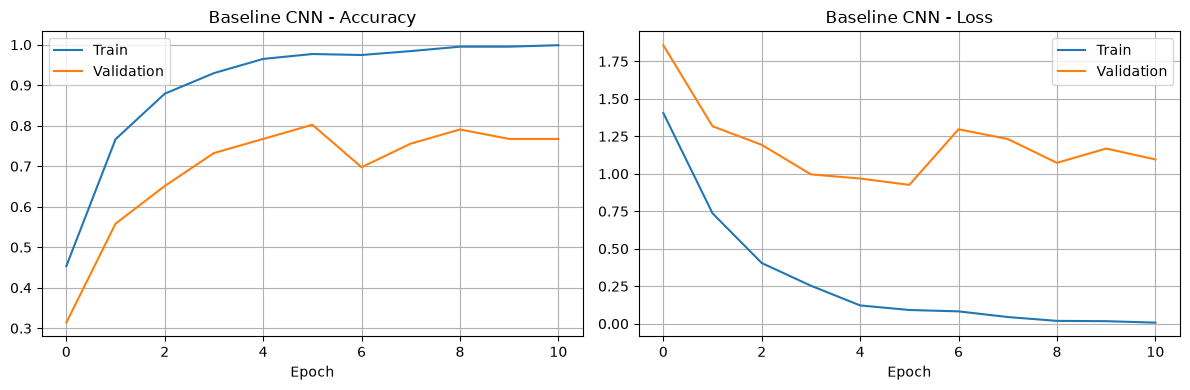

In [33]:
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight,
    callbacks=make_callbacks(patience=5),
    verbose=1,
)

plot_history(history_baseline.history, "Baseline CNN", "baseline_curves.png")
baseline_model.save(MODELS_DIR / "baseline_cnn_v2.keras")

## 6. Improved CNN

Deeper CNN with augmentation layers (active only during training), batch norm, dropout and L2.

No horizontal flips on purpose: flipping would turn `turn_left` into `turn_right`.

In [49]:
def build_improved_model():
    data_augmentation = keras.Sequential([
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.08, 0.08),
    ], name="data_augmentation")

    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(len(classes), activation="softmax"),
    ], name="improved_cnn")

    model.compile(optimizer=Adam(learning_rate=5e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


improved_model = build_improved_model()
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,022 (367.27 KB)

 Trainable params: 94,022 (367.27 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
def build_improved_model():
    data_augmentation = keras.Sequential([
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.05, 0.05),
    ], name="data_augmentation")

    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(len(classes), activation="softmax"),
    ], name="improved_cnn")

    model.compile(optimizer=Adam(learning_rate=5e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

improved_model = build_improved_model()

In [54]:
history_improved = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    class_weight=class_weight,
    callbacks=make_callbacks(patience=12, monitor="val_accuracy"),
    verbose=1,
)

Epoch 1/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.3495 - loss: 1.5410 - val_accuracy: 0.2093 - val_loss: 1.8190 - learning_rate: 5.0000e-04
Epoch 2/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.5707 - loss: 1.0652 - val_accuracy: 0.3721 - val_loss: 1.8050 - learning_rate: 5.0000e-04
Epoch 3/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7122 - loss: 0.8090 - val_accuracy: 0.4767 - val_loss: 1.7311 - learning_rate: 5.0000e-04
Epoch 4/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8174 - loss: 0.6047 - val_accuracy: 0.5349 - val_loss: 1.3824 - learning_rate: 5.0000e-04
Epoch 5/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8501 - loss: 0.4735 - val_accuracy: 0.5930 - val_loss: 1.1990 - learning_rate: 5.0000e-04
Epoch 6/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8791 - loss: 0.3973 - val_accuracy: 0.5698 - val_loss: 1.2673 - learning_rate: 5.0000e-04
Epoch 7/60
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8912 

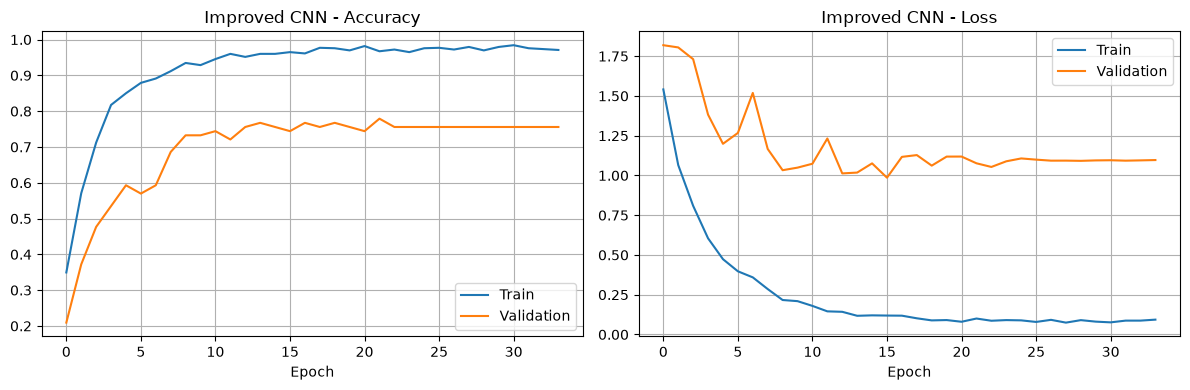

In [55]:
plot_history(history_improved.history, "Improved CNN", "improved_curves.png")
improved_model.save(MODELS_DIR / "improved_cnn_v2.keras")


Baseline CNN
------------
Accuracy:        0.7674
Macro precision: 0.7986
Macro recall:    0.7352
Macro F1:        0.6910

              precision    recall  f1-score   support

        stop       0.58      0.73      0.65        15
 speed_limit       0.94      0.88      0.91        17
    no_entry       0.90      0.95      0.92        19
  pedestrian       0.88      0.74      0.80        19
   turn_left       1.00      0.11      0.20         9
  turn_right       0.50      1.00      0.67         7

    accuracy                           0.77        86
   macro avg       0.80      0.74      0.69        86
weighted avg       0.82      0.77      0.75        86



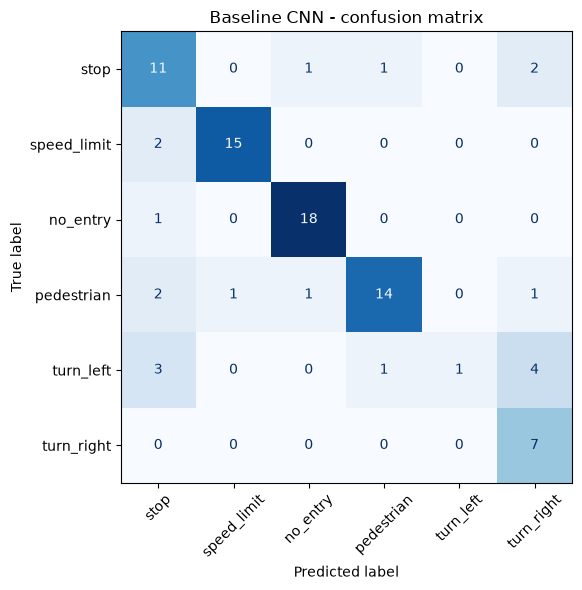


Improved CNN
------------
Accuracy:        0.8140
Macro precision: 0.8168
Macro recall:    0.7990
Macro F1:        0.7965

              precision    recall  f1-score   support

        stop       0.73      0.53      0.62        15
 speed_limit       0.85      1.00      0.92        17
    no_entry       0.76      0.84      0.80        19
  pedestrian       0.89      0.89      0.89        19
   turn_left       1.00      0.67      0.80         9
  turn_right       0.67      0.86      0.75         7

    accuracy                           0.81        86
   macro avg       0.82      0.80      0.80        86
weighted avg       0.82      0.81      0.81        86



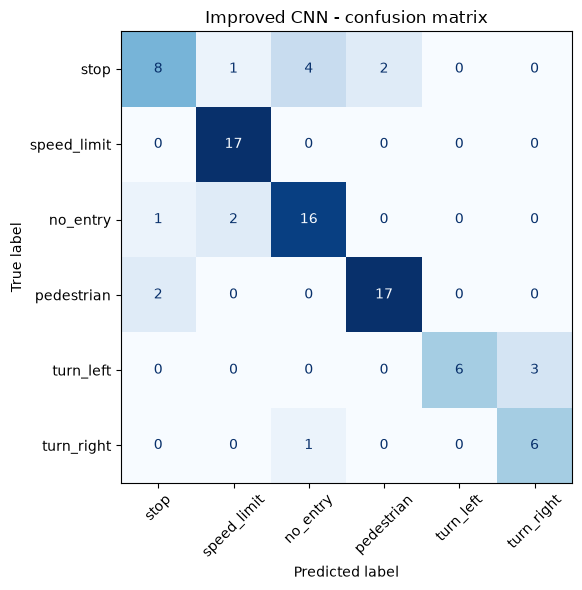


Transfer Learning (MobileNetV2)
-------------------------------
Accuracy:        0.8837
Macro precision: 0.8649
Macro recall:    0.8446
Macro F1:        0.8475

              precision    recall  f1-score   support

        stop       0.79      1.00      0.88        15
 speed_limit       1.00      0.82      0.90        17
    no_entry       0.90      0.95      0.92        19
  pedestrian       1.00      0.95      0.97        19
   turn_left       0.70      0.78      0.74         9
  turn_right       0.80      0.57      0.67         7

    accuracy                           0.88        86
   macro avg       0.86      0.84      0.85        86
weighted avg       0.89      0.88      0.88        86



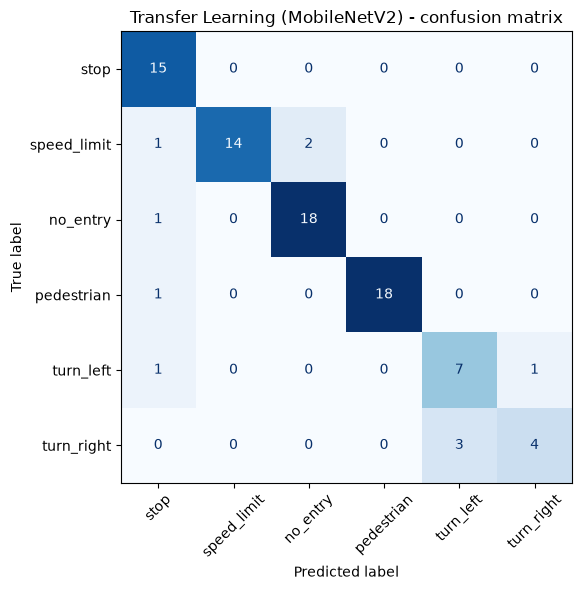


Transfer: own photos -> external
--------------------------------
Accuracy:        0.2093
Macro precision: 0.3667
Macro recall:    0.2340
Macro F1:        0.2159

              precision    recall  f1-score   support

        stop       0.26      0.60      0.36        15
 speed_limit       0.07      0.06      0.06        17
    no_entry       0.50      0.05      0.10        19
  pedestrian       0.67      0.11      0.18        19
   turn_left       0.67      0.44      0.53         9
  turn_right       0.04      0.14      0.06         7

    accuracy                           0.21        86
   macro avg       0.37      0.23      0.22        86
weighted avg       0.39      0.21      0.20        86



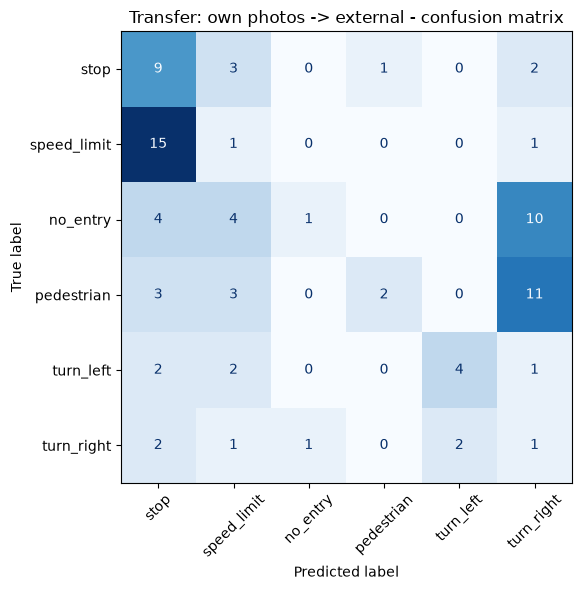

In [56]:
results.clear()
y_pred_baseline = evaluate_model(baseline_model, X_test, y_test, "Baseline CNN", "baseline")
y_pred_improved = evaluate_model(improved_model, X_test, y_test, "Improved CNN", "improved")
y_pred_transfer = evaluate_model(transfer_model, X_test, y_test, "Transfer Learning (MobileNetV2)", "transfer")
y_pred_cross = evaluate_model(cross_model, X_test, y_test, "Transfer: own photos -> external", "cross_domain")

## 7. Transfer learning (MobileNetV2)

Phase 1 trains only the new classification head on top of the frozen ImageNet backbone.
Phase 2 fine-tunes the last 30 backbone layers with a very small learning rate.
Inputs are in [0, 1], so `Rescaling(2, -1)` maps them to the [-1, 1] range MobileNetV2 expects.

In [36]:
def build_transfer_model():
    data_augmentation_tl = keras.Sequential([
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.08),
    ], name="traffic_sign_augmentation")

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation_tl(inputs)
    x = layers.Rescaling(scale=2.0, offset=-1.0)(x)     # [0,1] -> [-1,1]
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(len(classes), activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


def fine_tune(model, base_model, X, y, X_v, y_v, epochs=15, lr=3e-5, unfreeze_last=30):
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False          # keep BN statistics frozen

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model.fit(
        X, y,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=32,
        class_weight=class_weight,
        callbacks=make_callbacks(patience=5),
        verbose=1,
    )


transfer_model, base_model = build_transfer_model()
transfer_model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ traffic_sign_augmentation       │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
# Phase 1: train the head only
history_transfer = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight,
    callbacks=make_callbacks(patience=5),
    verbose=1,
)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.6868 - loss: 0.9881 - val_accuracy: 0.6860 - val_loss: 0.9260 - learning_rate: 5.0000e-04
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9262 - loss: 0.2798 - val_accuracy: 0.7442 - val_loss: 0.7451 - learning_rate: 5.0000e-04
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9625 - loss: 0.1727 - val_accuracy: 0.7558 - val_loss: 0.7188 - learning_rate: 5.0000e-04
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9649 - loss: 0.1528 - val_accuracy: 0.7558 - val_loss: 0.6288 - learning_rate: 5.0000e-04
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9770 - loss: 0.1203 - val_accuracy: 0.7907 - val_loss: 0.6442 - learning_rate: 5.0000e-04
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9782 - loss: 0.1002 - val_accuracy: 0.8256 - val_loss: 0.5511 - learning_rate: 5.0000e-04
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9758

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.9782 - loss: 0.1031 - val_accuracy: 0.8140 - val_loss: 0.5087 - learning_rate: 3.0000e-05
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9831 - loss: 0.0682 - val_accuracy: 0.8721 - val_loss: 0.5017 - learning_rate: 3.0000e-05
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9794 - loss: 0.0820 - val_accuracy: 0.8256 - val_loss: 0.5466 - learning_rate: 3.0000e-05
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9794 - loss: 0.0746 - val_accuracy: 0.8372 - val_loss: 0.4802 - learning_rate: 3.0000e-05
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9782 - loss: 0.0660 - val_accuracy: 0.8023 - val_loss: 0.6092 - learning_rate: 3.0000e-05
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9807 - loss: 0.0677
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-05.
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9807 - l

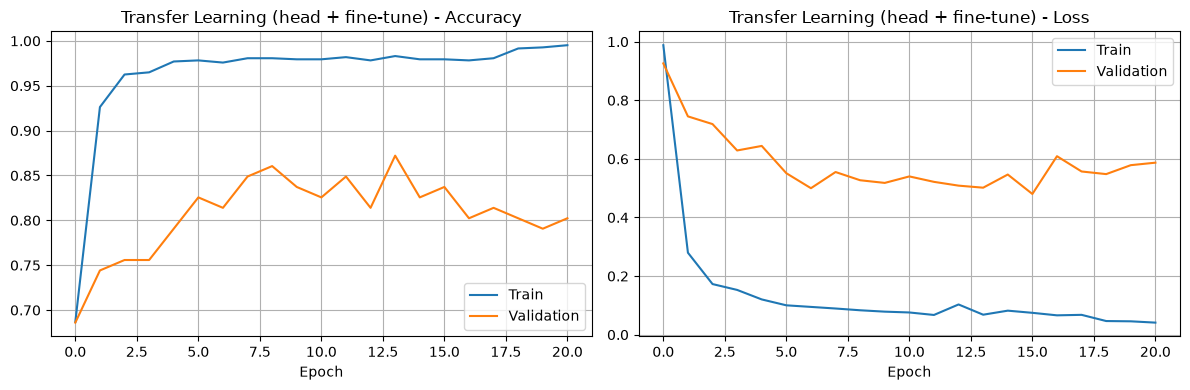

In [38]:
# Phase 2: fine-tune the top of the backbone
fine_tune_history = fine_tune(transfer_model, base_model, X_train, y_train, X_val, y_val)

plot_history(merge_histories(history_transfer, fine_tune_history),
             "Transfer Learning (head + fine-tune)", "transfer_curves.png")
transfer_model.save(MODELS_DIR / "transfer_mobilenetv2_v2.keras")

## 8. Evaluation on the held-out test set

The test set was never used for training, validation or early stopping.

In [39]:
results = []   # collects one row per model for the comparison table


def evaluate_model(model, x_data, y_true, model_name, save_prefix=None):
    y_pred = np.argmax(model.predict(x_data, verbose=0), axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro precision: {prec:.4f}")
    print(f"Macro recall:    {rec:.4f}")
    print(f"Macro F1:        {f1:.4f}\n")
    print(classification_report(
        y_true, y_pred,
        labels=np.arange(len(classes)),
        target_names=classes,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"{model_name} - confusion matrix")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(RESULTS_DIR / f"{save_prefix}_confusion_matrix.png", dpi=150)
    plt.show()

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro precision": prec,
        "Macro recall": rec,
        "Macro F1": f1,
    })
    return y_pred


Baseline CNN
------------
Accuracy:        0.7674
Macro precision: 0.7986
Macro recall:    0.7352
Macro F1:        0.6910

              precision    recall  f1-score   support

        stop       0.58      0.73      0.65        15
 speed_limit       0.94      0.88      0.91        17
    no_entry       0.90      0.95      0.92        19
  pedestrian       0.88      0.74      0.80        19
   turn_left       1.00      0.11      0.20         9
  turn_right       0.50      1.00      0.67         7

    accuracy                           0.77        86
   macro avg       0.80      0.74      0.69        86
weighted avg       0.82      0.77      0.75        86



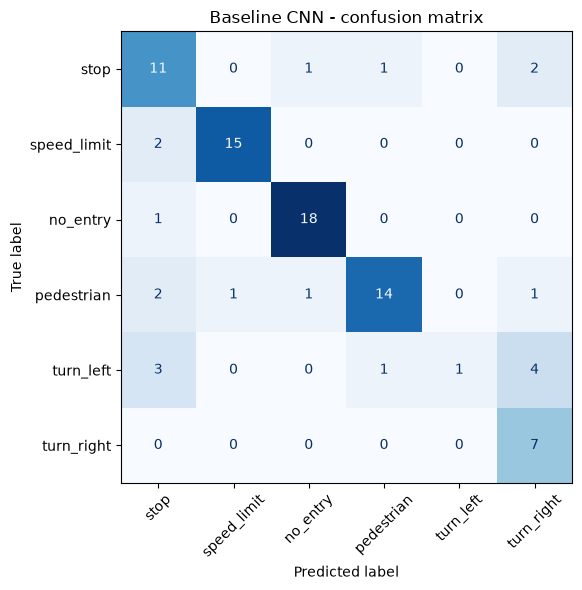

In [ ]:
results[:] = [r for r in results if r["Model"] != "Improved CNN"]


Improved CNN
------------
Accuracy:        0.1977
Macro precision: 0.0329
Macro recall:    0.1667
Macro F1:        0.0550

              precision    recall  f1-score   support

        stop       0.00      0.00      0.00        15
 speed_limit       0.20      1.00      0.33        17
    no_entry       0.00      0.00      0.00        19
  pedestrian       0.00      0.00      0.00        19
   turn_left       0.00      0.00      0.00         9
  turn_right       0.00      0.00      0.00         7

    accuracy                           0.20        86
   macro avg       0.03      0.17      0.06        86
weighted avg       0.04      0.20      0.07        86



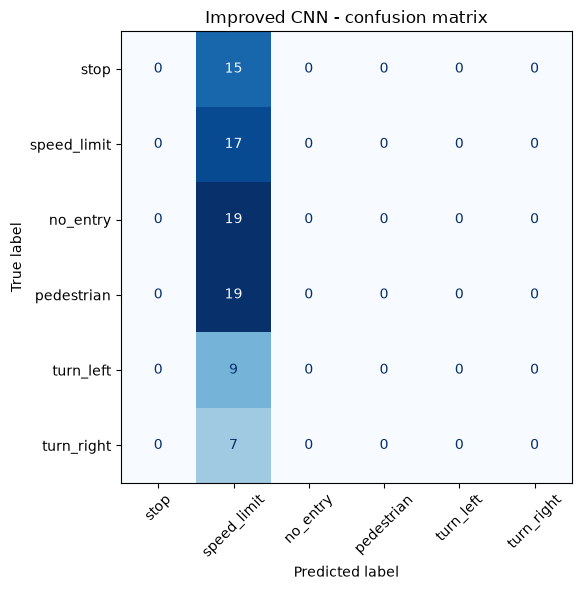

In [41]:
y_pred_improved = evaluate_model(improved_model, X_test, y_test, "Improved CNN", "improved")


Transfer Learning (MobileNetV2)
-------------------------------
Accuracy:        0.8837
Macro precision: 0.8649
Macro recall:    0.8446
Macro F1:        0.8475

              precision    recall  f1-score   support

        stop       0.79      1.00      0.88        15
 speed_limit       1.00      0.82      0.90        17
    no_entry       0.90      0.95      0.92        19
  pedestrian       1.00      0.95      0.97        19
   turn_left       0.70      0.78      0.74         9
  turn_right       0.80      0.57      0.67         7

    accuracy                           0.88        86
   macro avg       0.86      0.84      0.85        86
weighted avg       0.89      0.88      0.88        86



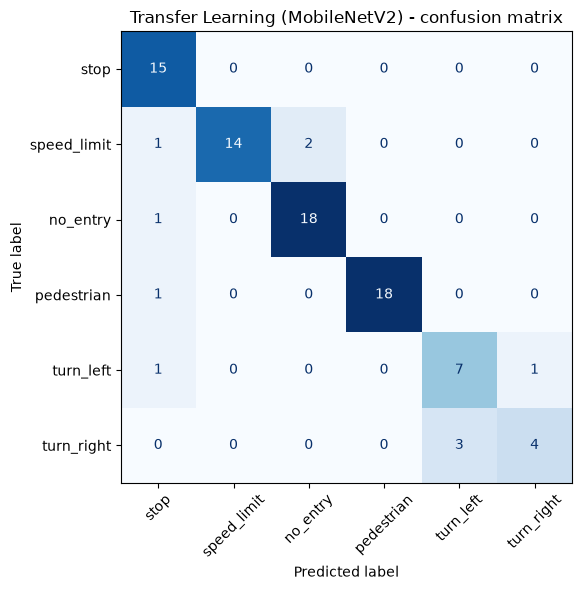

In [42]:
y_pred_transfer = evaluate_model(transfer_model, X_test, y_test, "Transfer Learning (MobileNetV2)", "transfer")

## 9. Model comparison

,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
Baseline CNN,0.7674,0.7986,0.7352,0.6910
Improved CNN,0.1977,0.0329,0.1667,0.0550
Transfer Learning (MobileNetV2),0.8837,0.8649,0.8446,0.8475


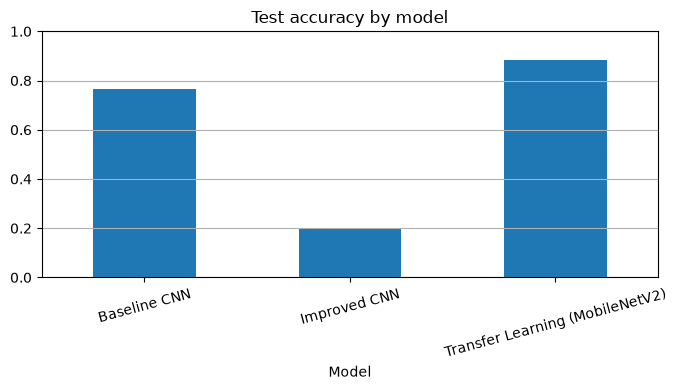

In [43]:
comparison = pd.DataFrame(results).set_index("Model").round(4)
display(comparison)
comparison.to_csv(RESULTS_DIR / "model_comparison.csv")

comparison["Accuracy"].plot(kind="bar", figsize=(7, 4), rot=15, title="Test accuracy by model")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=150)
plt.show()

## 10. Look at the mistakes

Viewing misclassified test images is the fastest way to find mislabeled or confusing data.

10 misclassified out of 86 test images


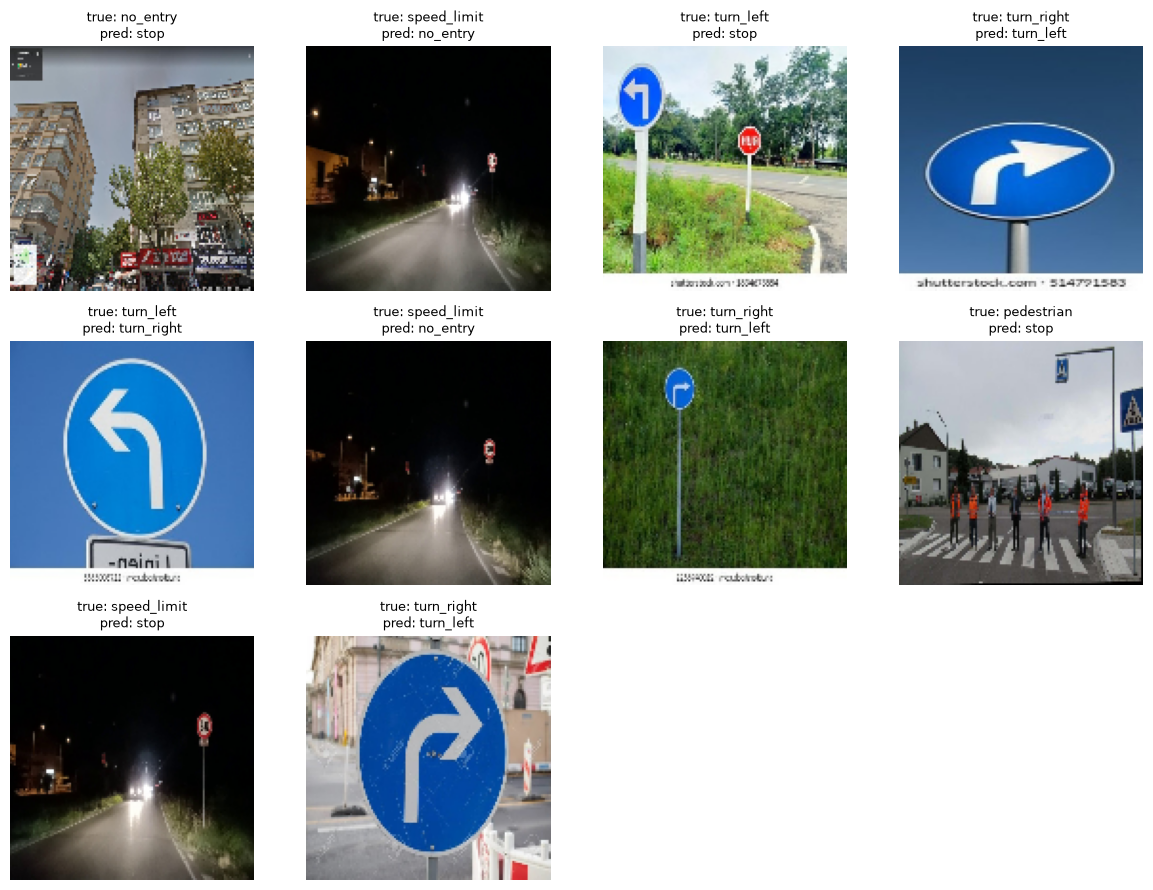

In [44]:
wrong = np.where(y_pred_transfer != y_test)[0]
print(f"{len(wrong)} misclassified out of {len(y_test)} test images")

show = wrong[:12]
if len(show):
    plt.figure(figsize=(12, 9))
    for i, idx in enumerate(show):
        plt.subplot(3, 4, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f"true: {classes[y_test[idx]]}\npred: {classes[y_pred_transfer[idx]]}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "transfer_misclassified.png", dpi=150)
    plt.show()

## 11. (Optional) Cross-domain experiment

Train the transfer model **only** on own photos + their augmented copies, then test on all
`external/` images. Report this as a generalization experiment: it shows how much performance
drops when the test images come from a different source than the training images.

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.7803 - loss: 0.6999 - val_accuracy: 0.1744 - val_loss: 2.2344 - learning_rate: 5.0000e-04
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9982 - loss: 0.0700 - val_accuracy: 0.2209 - val_loss: 2.3983 - learning_rate: 5.0000e-04
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9982 - loss: 0.0439
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9982 - loss: 0.0439 - val_accuracy: 0.2442 - val_loss: 2.4533 - learning_rate: 5.0000e-04
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 1.0000 - loss: 0.0345 - val_accuracy: 0.2326 - val_loss: 2.5102 - learning_rate: 2.5000e-04
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 0.0334
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 1.0000 - loss: 0

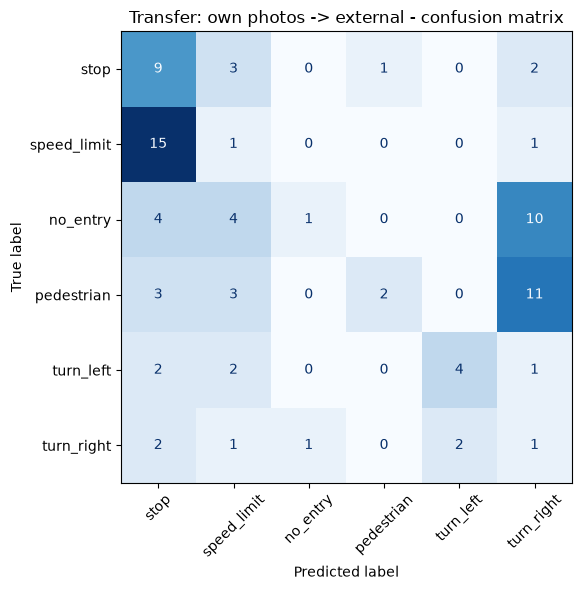

In [45]:
X_own = np.concatenate([X_original, X_augmented], axis=0)
y_own = np.concatenate([y_original, y_augmented], axis=0)

cross_model, cross_base = build_transfer_model()

cw_own = dict(enumerate(
    compute_class_weight("balanced", classes=np.arange(len(classes)), y=y_own)
))

# External val share is used only for early stopping / LR scheduling here
h1 = cross_model.fit(
    X_own, y_own,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=32,
    class_weight=cw_own,
    callbacks=make_callbacks(patience=5),
    verbose=1,
)

# Evaluate on external images that were NOT used for early stopping
_ = evaluate_model(cross_model, X_test, y_test, "Transfer: own photos -> external", "cross_domain")

In [46]:
# Final table including the optional cross-domain row
comparison = pd.DataFrame(results).set_index("Model").round(4)
display(comparison)
comparison.to_csv(RESULTS_DIR / "model_comparison.csv")

,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
Baseline CNN,0.7674,0.7986,0.7352,0.6910
Improved CNN,0.1977,0.0329,0.1667,0.0550
Transfer Learning (MobileNetV2),0.8837,0.8649,0.8446,0.8475
Transfer: own photos -> external,0.2093,0.3667,0.2340,0.2159
